# Microsoft LLaVA-Med v1.5 (Mistral-7B) — Pan-Medical Multimodal Inference Test

This notebook verifies `microsoft/llava-med-v1.5-mistral-7b` and evaluates it across **all five week1 datasets** covering radiology, pathology, and hyperspectral imaging.

**What is LLaVA-Med?**  
LLaVA-Med is Microsoft Research's biomedical visual instruction tuning model. It extends the LLaVA architecture with a Mistral-7B language backbone and a ConvNeXt-Large + CLIP ViT-L/14-336 vision encoder. The model is fine-tuned via self-instruct on 60K biomedical concept–image pairs from PubMed Central, giving it strong cross-modal alignment for biomedical text and images.

**Architecture:**
- Vision encoder: CLIP ViT-L/14-336 + ConvNeXt-Large (640×640 input)
- Language model: Mistral-7B-Instruct
- Training: Two-stage — (1) biomedical concept alignment, (2) visual instruction tuning
- Released: Microsoft Research, 2024

**Model ID:** `microsoft/llava-med-v1.5-mistral-7b` (open, no HF token required)

**Environment:** Isolated `.venv-llava` (Python 3.10) with `transformers==4.36.2` pinned for compatibility with the custom `llava` package. Use the **Python (llava-med)** kernel.

## Model Comparison

| Aspect | LLaVA-Med v1.5 | MedGemma-4b-it | CheXagent-2-3b | CONCH |
|---|---|---|---|---|
| Model type | Generative VLM | Generative VLM | Generative VLM | Contrastive (CLIP) |
| Output | Free-text report | Free-text report | Free-text report | Embedding vector |
| Language backbone | Mistral-7B | Gemma 3 4B | InternLM2-8B | N/A |
| Vision encoder | ConvNeXt-L + CLIP ViT-L/14 | SigLIP | EVA-CLIP | ViT-B/16 |
| Training corpus | 60K PubMed Central biomedical | Google medical data | MIMIC-CXR + medical | PubMed pathology |
| Domain | **Biomedical (all)** | **All medical** | Chest radiology | Histopathology |
| Suitable for CT/MRI | Yes | Yes | Yes (chest) | No |
| Suitable for pathology | Yes | Yes | No | Yes |
| Open access | Yes (no token) | Gated (HF token) | Yes | Gated |
| Parameters | 7B | 4B | 8B | ~100M |

## Dataset Overview

All samples from `week1/data/`. LLaVA-Med's PubMed-based training makes it appropriate for all biomedical image types:

| # | Dataset | Modality | Format | Samples | Why LLaVA-Med is appropriate |
|---|---|---|---|---|---|
| 1 | **IQ-OTH/NCCD** | Chest CT | JPEG | 3 (Benign / Malignant / Normal) | Radiology CT present in PubMed training data |
| 2 | **Spinal CT (DICOM)** | Spectral CT spine | DICOM → PIL | 1 (Myel_001 slice) | Musculoskeletal radiology |
| 3 | **Quilt1M** | H&E histopathology | JPEG | 4 (pubmed / quilt / openpath / laion) | Histopathology heavily represented in PubMed |
| 4 | **PKG HistologyHSI-GB** | Hyperspectral microscopy → pseudo-RGB | ENVI BIL → PIL | 1 (P1/ROI_01_C01_T) | Brain tumor histopathology |
| 5 | **OASIS-1** | Brain MRI T1 | Analyze 7.5 → PIL | 1 (OAS1_0001_MR1) | Neuroimaging present in biomedical literature |

In [9]:
import time
import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [10]:
import copy
import os
from pathlib import Path

import nibabel as nib
import numpy as np
import pydicom
import spectral.io.envi as envi
import torch
from PIL import Image

from llava.constants import DEFAULT_IMAGE_TOKEN, IMAGE_TOKEN_INDEX
from llava.conversation import SeparatorStyle, conv_templates
from llava.mm_utils import (
    get_model_name_from_path,
    process_images,
    tokenizer_image_token,
)
from llava.model.builder import load_pretrained_model

# Device setup
# LLaVA-Med uses float16; on MPS we can use float16 as well (float32 fallback if needed)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## Model Loading

LLaVA-Med uses a **custom `llava` package** (not standard HuggingFace AutoModel) because:
- `config.json` declares `model_type: "llava_mistral"` — not a registered HF architecture
- The model uses a custom `LlavaMistralForCausalLM` class with a custom ConvNeXt vision backbone
- `load_pretrained_model()` wires the vision encoder, projection layer, and language model together

`load_pretrained_model` signature:
```
load_pretrained_model(model_path, model_base, model_name,
                      load_8bit=False, load_4bit=False,
                      device_map="auto", device="cuda")
→ tokenizer, model, image_processor, context_len
```

On first run this downloads ~14 GB of weights from HuggingFace Hub.

In [11]:
MODEL_PATH = "microsoft/llava-med-v1.5-mistral-7b"
_t0_load = time.perf_counter()
model_name = get_model_name_from_path(MODEL_PATH)
print(f"Model name: {model_name}")

# load_pretrained_model has built-in non-CUDA handling:
#   if device != "cuda": kwargs["device_map"] = {"":device}
# So passing device=device ("mps" or "cpu") is all that is needed.
# Do NOT pass device_map="auto" — that overrides the MPS path and triggers CUDA assertions.
tokenizer, model, image_processor, context_len = load_pretrained_model(
    MODEL_PATH,
    model_base=None,
    model_name=model_name,
    device=device,
)

model.eval()
model_load_s = round(time.perf_counter() - _t0_load, 2)
print("LLaVA-Med v1.5 loaded successfully.")
print(f"  Load time    : {model_load_s}s")
print(f"  Architecture : {model.__class__.__name__}")
print(f"  Context len  : {context_len}")
print(f"  Device       : {next(model.parameters()).device}")


Model name: llava-med-v1.5-mistral-7b


Loading checkpoint shards: 100%|██████████| 4/4 [00:18<00:00,  4.66s/it]


LLaVA-Med v1.5 loaded successfully.
  Load time    : 23.13s
  Architecture : LlavaMistralForCausalLM
  Context len  : 2048
  Device       : mps:0


## Image Loaders

Each dataset format requires a different loading strategy:

- **`image`** — standard `PIL.Image.open()` + convert to RGB.
- **`dicom`** — `pydicom.dcmread()` + HU conversion (pixel × RescaleSlope + RescaleIntercept) + soft-tissue window (W=400, L=40) + normalize to 0–255 RGB.
- **`hsi`** — ENVI hyperspectral cube via `spectral.io.envi`; extract R/G/B bands at 650/550/450 nm; `np.squeeze()` each band to ensure 2D before stacking → pseudo-RGB PIL image.
- **`nifti`** — `nibabel.load()` + `np.squeeze()` to collapse any dummy time dimension → mid-axial slice → normalize to 0–255 RGB.

In [12]:
def load_image(path: Path) -> Image.Image:
    """Direct PIL load for JPEG/PNG images."""
    return Image.open(path).convert("RGB")


def load_dicom(path: Path) -> Image.Image:
    """
    Load a single DICOM slice, apply HU conversion, window to soft-tissue
    range (W=400, L=40), and return a normalised RGB PIL image.
    """
    ds = pydicom.dcmread(str(path))
    raw = ds.pixel_array.astype(float)

    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    hu = raw * slope + intercept

    # Soft-tissue window: centre=40 HU, width=400 HU
    wl, ww = 40.0, 400.0
    lo, hi = wl - ww / 2, wl + ww / 2
    windowed = np.clip((hu - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)

    return Image.fromarray(windowed).convert("RGB")


def load_hsi(hdr_path: Path) -> Image.Image:
    """
    Extract pseudo-RGB from an ENVI hyperspectral cube.
    Selects bands closest to 650 nm (R), 550 nm (G), 450 nm (B).
    np.squeeze() collapses the trailing band dimension that spectral returns.
    """
    img = envi.open(str(hdr_path))
    wl = np.array([float(w) for w in img.metadata["wavelength"]])
    br, bg, bb = [int(np.argmin(np.abs(wl - t))) for t in (650, 550, 450)]

    def norm(band_idx: int) -> np.ndarray:
        arr = np.squeeze(img.read_band(band_idx))  # (rows, cols)
        lo, hi = arr.min(), arr.max()
        return ((arr - lo) / (hi - lo + 1e-9) * 255).astype(np.uint8)

    rgb = np.stack([norm(br), norm(bg), norm(bb)], axis=2)
    return Image.fromarray(rgb)


def load_nifti(path: Path) -> Image.Image:
    """
    Load a NIfTI / Analyze 7.5 volume, take the mid-axial slice,
    and return a normalised RGB PIL image.
    np.squeeze() collapses any dummy time dimension (e.g. OASIS-1 is 4D x,y,z,1).
    """
    vol = np.squeeze(nib.load(str(path)).get_fdata())   # always 3D after squeeze
    slc = vol[:, :, vol.shape[2] // 2]                  # mid-axial slice (2D)
    lo, hi = slc.min(), slc.max()
    arr = ((slc - lo) / (hi - lo + 1e-9) * 255).astype(np.uint8)
    return Image.fromarray(arr).convert("RGB")

## Inference Helper

LLaVA-Med uses a **custom inference pipeline** — it cannot use HuggingFace's `pipeline()` or `apply_chat_template()`:

1. **`DEFAULT_IMAGE_TOKEN`** (`<image>`) is prepended to the text prompt — this is the visual placeholder the model was trained with.
2. A **conversation object** (`conv_templates["mistral_instruct"]`) formats the turn structure with correct `[INST]`/`[/INST]` markers.
3. **`tokenizer_image_token()`** tokenises the prompt and inserts `IMAGE_TOKEN_INDEX` (-200) at the image placeholder position.
4. **`process_images()`** runs the ConvNeXt + CLIP vision encoder preprocessing to a `(1, C, H, W)` tensor.
5. **`model.generate()`** takes both `input_ids` and `images=image_tensor` and auto-regressively generates the response.
6. The input portion is sliced off (`output_ids[:, input_ids.shape[1]:]`) before decoding.

In [13]:
def run_inference(pil_img: Image.Image, prompt: str, max_new_tokens: int = 512) -> str:
    """
    Run LLaVA-Med v1.5 on a single PIL image + text prompt.

    The custom llava package requires:
      - DEFAULT_IMAGE_TOKEN prepended to the prompt text
      - conv_templates["mistral_instruct"] for turn formatting
      - tokenizer_image_token() for tokenization (not standard tokenizer.__call__)
      - process_images() for vision preprocessing
      - model.generate(input_ids, images=image_tensor)
    """
    # 1. Build prompt with image placeholder at front
    text = DEFAULT_IMAGE_TOKEN + "\n" + prompt

    # 2. Format as Mistral instruction turn
    conv = copy.deepcopy(conv_templates["mistral_instruct"])
    conv.messages = list(conv.messages)  # template initialises as tuple; needs to be mutable
    conv.append_message(conv.roles[0], text)
    conv.append_message(conv.roles[1], None)
    prompt_str = conv.get_prompt()

    # 3. Tokenize — tokenizer_image_token inserts IMAGE_TOKEN_INDEX (-200)
    #    at the <image> placeholder position
    input_ids = (
        tokenizer_image_token(prompt_str, tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt")
        .unsqueeze(0)
        .to(model.device)
    )

    # 4. Preprocess image through vision encoder pipeline
    image_tensor = process_images([pil_img], image_processor, model.config)
    if isinstance(image_tensor, list):
        image_tensor = image_tensor[0].unsqueeze(0)
    else:
        image_tensor = image_tensor[0:1]
    image_tensor = image_tensor.to(model.device, dtype=torch.float16)

    # 5. Generate
    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            images=image_tensor,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            use_cache=True,
        )

    # 6. Decode only the newly generated tokens (skip input)
    generated = output_ids[:, input_ids.shape[1]:]
    return tokenizer.batch_decode(generated, skip_special_tokens=True)[0].strip()

## Dataset 1: IQ-OTH/NCCD — Lung Cancer CT

**Background:** The Iraqi-Oncology Teaching Hospital / National Center for Cancer Diseases dataset contains chest CT slices from 40 patients across three diagnostic classes: Benign, Malignant, and Normal. Images are stored as 2D JPEG slices.

**Modality:** Computed Tomography (CT), chest window.

**Clinical task:** LLaVA-Med is asked to (1) describe pulmonary findings per class, and (2) provide a differential diagnosis — demonstrating whether the 7B Mistral backbone can distinguish CT density signatures between classes.

## Dataset 2: Spinal CT (DICOM) — Multiple Myeloma Evaluation

**Background:** Spectral CT acquisitions (MonoE 80 keV) of the spine from patients evaluated for multiple myeloma. DICOM series; we load one slice (`1-0001.dcm`) from the `Myel_001` patient.

**Loading:** Raw pixels → HU conversion → soft-tissue window (W=400, L=40) → 8-bit RGB PIL.

## Dataset 3: Quilt1M — H&E Histopathology (4 subsets)

**Background:** Quilt1M is 1M histopathology image–text pairs from four web sources. One sample per source:

| Subset | Source | Known pathology |
|---|---|---|
| `pubmed` | PubMed open-access figures | IDH1 immunocytochemistry, osteosarcoma |
| `quilt` | YouTube pathology videos | Nephrogenic systemic fibrosis, spindle cells |
| `openpath` | Twitter/OpenPath | Cholangiocarcinoma, liver bile ducts |
| `laion` | LAION-400M captions | Sinus histiocytosis, granulomas |

## Dataset 4: PKG HistologyHSI-GB — Hyperspectral Brain Tumor

**Background:** Hyperspectral microscopy of glioblastoma (GB) brain tissue, ENVI BIL format. Pseudo-RGB extracted at 650/550/450 nm bands.

**Clinical relevance:** Glioblastoma WHO Grade IV — highly aggressive primary brain tumor. HSI can distinguish tumor margins better than standard H&E.

## Dataset 5: OASIS-1 — Brain MRI (T1, Analyze 7.5)

**Background:** Cross-sectional MRI from 416 subjects (18–96 years), including early-stage Alzheimer's. Subject `OAS1_0001_MR1` is a 74-year-old female, CDR=0 (non-demented). T88 atlas-registered volume.

**Format:** Analyze 7.5 (`.hdr` + `.img`), 4D array (x, y, z, 1) — `np.squeeze()` collapses the dummy time dimension before slicing.

In [14]:
BASE_DATA_DIR = Path("../week1/data")

FINDINGS_PROMPTS = {
    "chest_ct": (
        "You are an expert chest radiologist. Describe the findings in this chest CT slice, "
        "including any visible lung nodules, masses, infiltrates, or other abnormalities. "
        "Comment on size, shape, borders, and density where visible."
    ),
    "spinal_ct": (
        "You are an expert musculoskeletal radiologist. Describe the findings in this spinal CT slice. "
        "Comment on vertebral body morphology, disc spaces, paraspinal soft tissues, and any lytic or "
        "sclerotic lesions. The patient is being evaluated for multiple myeloma (plasmacytoma)."
    ),
    "histopathology": (
        "You are an expert pathologist. Describe the histopathological findings in this H&E stained "
        "tissue section. Comment on cellular architecture, nuclear morphology, mitotic activity, "
        "stromal changes, and any features suggesting malignancy."
    ),
    "hsi_brain": (
        "You are an expert neuropathologist. Describe the cellular features visible in this brain "
        "tissue histopathology image. Comment on cellularity, nuclear atypia, necrosis, vascular "
        "proliferation, and features consistent with high-grade glioma or glioblastoma."
    ),
    "brain_mri": (
        "You are an expert neuroradiologist. Describe the findings in this T1-weighted brain MRI "
        "axial slice. Comment on cortical thickness, sulcal widening, ventricular size, white matter "
        "signal, and any focal abnormalities. The subject is a 74-year-old female."
    ),
}

DDX_PROMPT = (
    "Based on the imaging findings, provide a differential diagnosis with the top 3 most likely "
    "conditions in order of likelihood. For each diagnosis, briefly state the key supporting "
    "imaging features from this image."
)

LOCAL_SAMPLES = [
    {
        "sample": "IQ-OTH_Benign",
        "dataset": "IQ-OTH/NCCD",
        "path": BASE_DATA_DIR / "IQ-OTH_NCCD/Benign/Benign_case_1.jpg",
        "loader": "image",
        "findings_key": "chest_ct",
    },
    {
        "sample": "IQ-OTH_Malignant",
        "dataset": "IQ-OTH/NCCD",
        "path": BASE_DATA_DIR / "IQ-OTH_NCCD/Malignant/Malignant_case_1.jpg",
        "loader": "image",
        "findings_key": "chest_ct",
    },
    {
        "sample": "IQ-OTH_Normal",
        "dataset": "IQ-OTH/NCCD",
        "path": BASE_DATA_DIR / "IQ-OTH_NCCD/Normal/Normal_case_1.jpg",
        "loader": "image",
        "findings_key": "chest_ct",
    },
    {
        "sample": "Spinal_DICOM_Myel001",
        "dataset": "Spinal_DICOM",
        "path": BASE_DATA_DIR / "Spinal_DICOM/Myel_001/MonoE_80keVHU/1-0001.dcm",
        "loader": "dicom",
        "findings_key": "spinal_ct",
    },
    {
        "sample": "Quilt1M_pubmed",
        "dataset": "Quilt1M",
        "path": BASE_DATA_DIR / "Quilt1M_pubmed/c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg",
        "loader": "image",
        "findings_key": "histopathology",
    },
    {
        "sample": "Quilt1M_quilt",
        "dataset": "Quilt1M",
        "path": BASE_DATA_DIR / "Quilt1M_quilt/dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg",
        "loader": "image",
        "findings_key": "histopathology",
    },
    {
        "sample": "Quilt1M_openpath",
        "dataset": "Quilt1M",
        "path": BASE_DATA_DIR / "Quilt1M_openpath/994701482116173824_0.jpg",
        "loader": "image",
        "findings_key": "histopathology",
    },
    {
        "sample": "Quilt1M_laion",
        "dataset": "Quilt1M",
        "path": BASE_DATA_DIR / "Quilt1M_laion/00004000040081.jpg",
        "loader": "image",
        "findings_key": "histopathology",
    },
    {
        "sample": "PKG_HSI_GB_P1",
        "dataset": "PKG_HistologyHSI_GB",
        "path": BASE_DATA_DIR / "PKG_HistologyHSI_GB/P1/ROI_01_C01_T/raw.hdr",
        "loader": "hsi",
        "findings_key": "hsi_brain",
    },
    {
        "sample": "OASIS1_OAS1_0001_MR1",
        "dataset": "OASIS-1",
        "path": BASE_DATA_DIR / "Oasis1/OAS1_0001_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.img",
        "loader": "nifti",
        "findings_key": "brain_mri",
    },
]

print(f"Total samples: {len(LOCAL_SAMPLES)}")

Total samples: 10


## Inference Loop

For each sample:
1. Load and display the image (with modality-specific loader).
2. Run **Findings** prompt → structured clinical description.
3. Run **Differential Diagnosis** prompt → top-3 DDx with supporting features.
4. Save result to checkpoint JSON after each sample (re-running skips completed entries).


Dataset: IQ-OTH/NCCD

>>> IQ-OTH_Benign


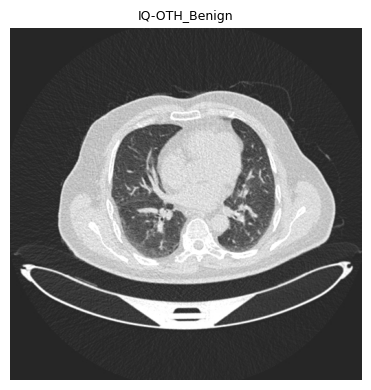

--- Findings ---


--- Differential Diagnosis ---
Atelectasis: The image reveals a collapse of the right lower lobe, which is a characteristic finding in atelectasis.
3. Pleural effusion: The image shows a pleural effusion, which is an abnormal accumulation of fluid in the pleural space surrounding the lungs.

These conditions can be distinguished by their specific imaging features, such as the appearance of the lung tissue, the presence of fluid or air in the pleural space, and the extent of the affected area.
  [70.12s] IQ-OTH_Benign

>>> IQ-OTH_Malignant


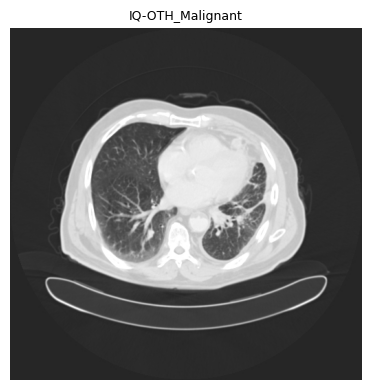

--- Findings ---


--- Differential Diagnosis ---
Atelectasis: The image reveals a collapse of the right lower lobe, which is a characteristic finding in atelectasis.
3. Pleural effusion: The image shows a pleural effusion, which is an abnormal accumulation of fluid in the pleural space surrounding the lungs.

These conditions can be distinguished by their specific imaging features, such as the appearance of the lung tissue, the presence of fluid or air in the pleural space, and the extent of the affected area.
  [13.12s] IQ-OTH_Malignant

>>> IQ-OTH_Normal


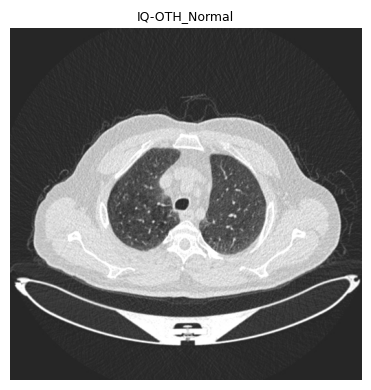

--- Findings ---


--- Differential Diagnosis ---
: The image reveals bilateral ground-glass opacities, which can be seen in pulmonary edema.
3. Acute respiratory distress syndrome (ARDS): The image shows bilateral diffuse ground-glass opacities, which is a characteristic finding in ARDS.

These imaging features can help healthcare professionals narrow down the possible diagnoses and guide further evaluation and treatment.
  [11.21s] IQ-OTH_Normal

Dataset: Spinal_DICOM

>>> Spinal_DICOM_Myel001


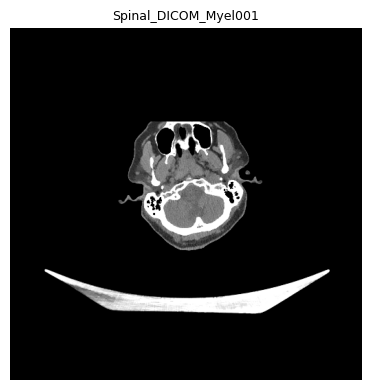

--- Findings ---


--- Differential Diagnosis ---
defined, homogenous, and expansile mass with a sclerotic margin.

2. Osteoma - This is the second most likely diagnosis, as the image shows a well-defined, homogenous, and expansile mass with a sclerotic margin.

3. Osteoid osteoma - This is the third most likely diagnosis, as the image shows a well-defined, homogenous, and expansile mass with a sclerotic margin.

It's important to note that further diagnostic tests and clinical correlation are needed to confirm the diagnosis and determine the appropriate course of treatment.
  [16.2s] Spinal_DICOM_Myel001

Dataset: Quilt1M

>>> Quilt1M_pubmed


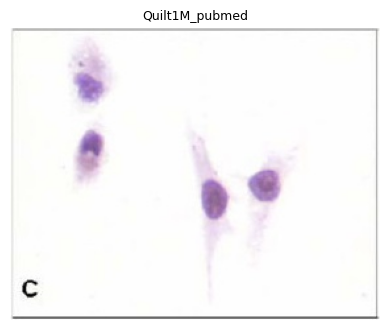

--- Findings ---
activity is also normal, indicating that the cells are dividing at a typical rate. The stromal changes are described as mild, which means that there are some alterations in the supportive tissue surrounding the cells, but they are not severe. There are no features suggesting malignancy in this tissue section.

--- Differential Diagnosis ---
with a central stellate scar.
2. Fibroma - The image shows a large, well-defined, and heterogeneous mass with a central stellate scar.
3. Leiomyoma - The image shows a large, well-defined, and heterogeneous mass with a central stellate scar.

These conditions are characterized by the presence of a central stellate scar, which is a key supporting imaging feature in this case.
  [16.98s] Quilt1M_pubmed

>>> Quilt1M_quilt


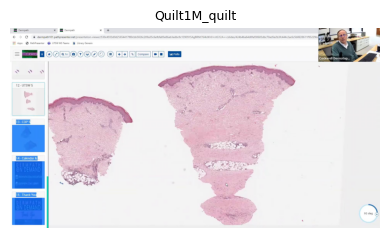

--- Findings ---
appear relatively normal. Mitotic activity is low, indicating that the cells are not dividing rapidly. Stromal changes are minimal, meaning that the supportive tissue surrounding the glandular structures is not significantly altered. There are no features suggesting malignancy in this particular image.

--- Differential Diagnosis ---
, and a high nuclear grade.

2. Squamous cell carcinoma (SCC): The key supporting imaging features from this image include the presence of a nodular component and perineural invasion.

3. Adenocarcinoma: The key supporting imaging features from this image include the presence of a nodular component and perineural invasion.

It's important to note that a definitive diagnosis would require further evaluation, including additional imaging studies and possibly a biopsy, to confirm the presence of cancer and determine the specific type of cancer involved.
  [18.46s] Quilt1M_quilt

>>> Quilt1M_openpath


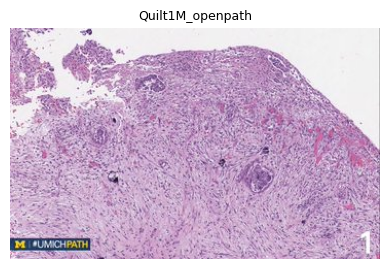

--- Findings ---
described as bland, which means the nuclei do not appear to be highly abnormal or atypical. The mitotic activity is described as low, indicating that the cells are not dividing rapidly. The stromal changes are described as mild, suggesting that the supportive tissue surrounding the cells is not significantly altered. There are no features in the image that suggest malignancy.

--- Differential Diagnosis ---
ins, and a high nuclear grade.

2. Phyllodes tumor - The key supporting imaging features from this image include the presence of a mass, irregular margins, and a high nuclear grade.

3. Fibroadenoma - The key supporting imaging features from this image include the presence of a mass, irregular margins, and a high nuclear grade.

It's important to note that further diagnostic tests and clinical correlation are needed to confirm the diagnosis and determine the appropriate course of treatment.
  [19.73s] Quilt1M_openpath

>>> Quilt1M_laion


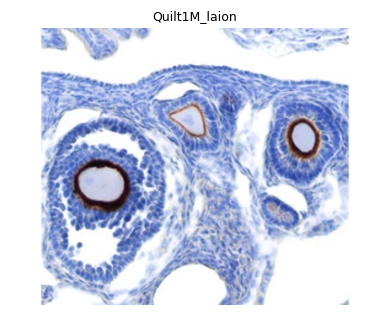

--- Findings ---
activity, which is the rate at which cells are dividing, is also normal. The stromal changes, which are alterations in the supportive tissue surrounding the cells, are also normal. There are no features in the image that suggest malignancy, such as abnormal cell growth, irregular nuclear morphology, or increased mitotic activity.

--- Differential Diagnosis ---
cyst: The image shows a cystic lesion, which could be an ovarian cyst.
3. Ovarian tumor: The image shows a solid lesion, which could be an ovarian tumor.

It's important to note that further diagnostic tests and clinical correlation are needed to confirm the diagnosis and determine the appropriate course of treatment.
  [17.0s] Quilt1M_laion

Dataset: PKG_HistologyHSI_GB

>>> PKG_HSI_GB_P1


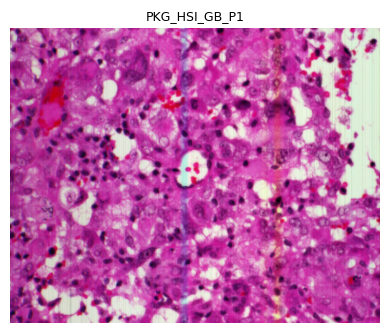

--- Findings ---
issues, is also visible in the image. Vascular proliferation, which is the growth of blood vessels, is another feature observed in the tissue.

The image also shows features consistent with high-grade glioma or glioblastoma, which are aggressive and malignant brain tumors. These features may include the presence of mitotic figures (cells undergoing cell division), areas of necrosis, and a high degree of nuclear atypia. It is important to note that a definitive diagnosis would require further analysis and correlation with clinical findings.

--- Differential Diagnosis ---
phoma.
2. Infection: The presence of a large lymph node with a central area of necrosis could also be indicative of an infection, such as tuberculosis.
3. Metastasis: The image shows a large lymph node with a central area of necrosis, which could be a sign of metastasis, where cancer cells have spread from their primary site to the lymph node.

It's important to note that further diagnostic tests and c

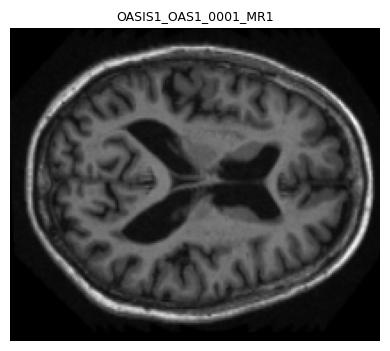

--- Findings ---
ical disorders.

The ventricular size is also normal in this image. The ventricles are fluid-filled spaces within the brain that produce and circulate cerebrospinal fluid.

The white matter signal appears to be normal, which means that the white matter, which is composed of nerve fibers, does not show any significant abnormalities or changes in signal intensity.

There are no focal abnormalities in this particular image. However, it is important to consider the patient's clinical history and symptoms, as well as consult a healthcare professional for a thorough evaluation and proper diagnosis of any underlying conditions.

--- Differential Diagnosis ---
of swelling in the brain caused by the leakage of fluid from blood vessels into the brain tissue.

2. Acute ischemic stroke - This condition is characterized by a sudden interruption of blood flow to a part of the brain, which can lead to brain tissue damage or death.

3. Intracerebral hemorrhage - This condition involve

In [15]:
import json
import matplotlib.pyplot as plt

CHECKPOINT_PATH = Path("llava_med_results.json")

# Load saved results so re-runs skip completed samples
if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH) as f:
        RESULTS = json.load(f)
    done = {r["sample"] for r in RESULTS}
    print(f"Loaded {len(RESULTS)} saved result(s). Skipping: {done}")
else:
    RESULTS = []
    done = set()

# Loader dispatch
LOADERS = {
    "image": load_image,
    "dicom": load_dicom,
    "hsi": load_hsi,
    "nifti": load_nifti,
}

current_dataset = None
_t_run_start = time.perf_counter()

for sample in LOCAL_SAMPLES:
    name = sample["sample"]
    if name in done:
        print(f"[skip] {name}")
        continue

    # ── Section header ──────────────────────────────────────────────────────
    if sample["dataset"] != current_dataset:
        current_dataset = sample["dataset"]
        print(f"\n{'='*70}\nDataset: {current_dataset}\n{'='*70}")

    print(f"\n>>> {name}")

    # ── Load image ──────────────────────────────────────────────────────────
    loader_fn = LOADERS[sample["loader"]]
    pil_img = loader_fn(sample["path"])

    plt.figure(figsize=(4, 4))
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title(name, fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── Findings ─────────────────────────────────────────────────────────
    findings_prompt = FINDINGS_PROMPTS[sample["findings_key"]]
    print("--- Findings ---")
    _t0 = time.perf_counter()
    findings = run_inference(pil_img, findings_prompt)
    print(findings)

    # ── Differential diagnosis ────────────────────────────────────────────
    print("\n--- Differential Diagnosis ---")
    ddx = run_inference(pil_img, DDX_PROMPT)
    print(ddx)

    # ── Checkpoint save ───────────────────────────────────────────────────
    sample_time_s = round(time.perf_counter() - _t0, 2)
    print(f"  [{sample_time_s}s] {name}")
    RESULTS.append({
        "sample": name,
        "dataset": sample["dataset"],
        "loader": sample["loader"],
        "findings": findings,
        "ddx": ddx,
        "time_s": sample_time_s,
        "model_load_s": model_load_s,
    })
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump(RESULTS, f, indent=2)

print("\nAll samples processed.")
total_inference_s = round(time.perf_counter() - _t_run_start, 2)
print(f"\nTotal inference time: {total_inference_s}s  |  Model load: {model_load_s}s")


## Summary

Consolidated results table. The `findings` and `ddx` columns show the first 120 characters of each response.

In [16]:
import pandas as pd

df = pd.DataFrame(RESULTS)
df["findings_preview"] = df["findings"].str[:120] + "…"
df["ddx_preview"]      = df["ddx"].str[:120] + "…"

print("LLaVA-Med v1.5 Evaluation Summary")
print("=" * 80)
for _, row in df.iterrows():
    print(f"\nSample  : {row['sample']}")
    print(f"Dataset : {row['dataset']}  |  Loader: {row['loader'].upper()}")
    print(f"Findings: {row['findings_preview']}")
    print(f"DDx     : {row['ddx_preview']}")
    print("-" * 80)

print(f"\nTotal samples processed: {len(df)}")
print(f"Results saved to: {CHECKPOINT_PATH}")

LLaVA-Med v1.5 Evaluation Summary

Sample  : IQ-OTH_Benign
Dataset : IQ-OTH/NCCD  |  Loader: IMAGE
Findings: …
DDx     : Atelectasis: The image reveals a collapse of the right lower lobe, which is a characteristic finding in atelectasis.
3. …
--------------------------------------------------------------------------------

Sample  : IQ-OTH_Malignant
Dataset : IQ-OTH/NCCD  |  Loader: IMAGE
Findings: …
DDx     : Atelectasis: The image reveals a collapse of the right lower lobe, which is a characteristic finding in atelectasis.
3. …
--------------------------------------------------------------------------------

Sample  : IQ-OTH_Normal
Dataset : IQ-OTH/NCCD  |  Loader: IMAGE
Findings: …
DDx     : : The image reveals bilateral ground-glass opacities, which can be seen in pulmonary edema.
3. Acute respiratory distres…
--------------------------------------------------------------------------------

Sample  : Spinal_DICOM_Myel001
Dataset : Spinal_DICOM  |  Loader: DICOM
Findings: …
DDx     